# HW03 KNN

Датасет: Breast Cancer Wisconsin (Diagnostic) Data Set

https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score, precision_score,recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
import plotly  

df = pd.read_csv("data.csv")


# Short Lookup

In [104]:
df.head()
df = df.drop(df.columns[-1], axis=1)

In [105]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [106]:
df.shape

(569, 32)

In [107]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [108]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [109]:
print(df['diagnosis'].value_counts())
print(df['diagnosis'].value_counts(normalize=True) * 100)

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [110]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


# Краткое описание по данным:

Размер датасета: 569 строк с 31 колонками.

В основном признаки -- числа с плавающей точкой, кроме id и типа опухоли -- (malignant/benign).

Пропусков нет.

Распределение осуществляется по 2 классам: доброкачественная опухоль (примерно 63% данных) и злокачественная -- прмиерно 37%. Датасет вполне сбалансирован.

Дубликатов строк нет.

# EDA + Data preparation

Пропусков к сожалению или к счастью нет.

Сделаем Binary Encoding диагнозов (так как у нас только 2 класса). Пусть злокачественная опухоль - 1, доброкач. - 0.

In [111]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


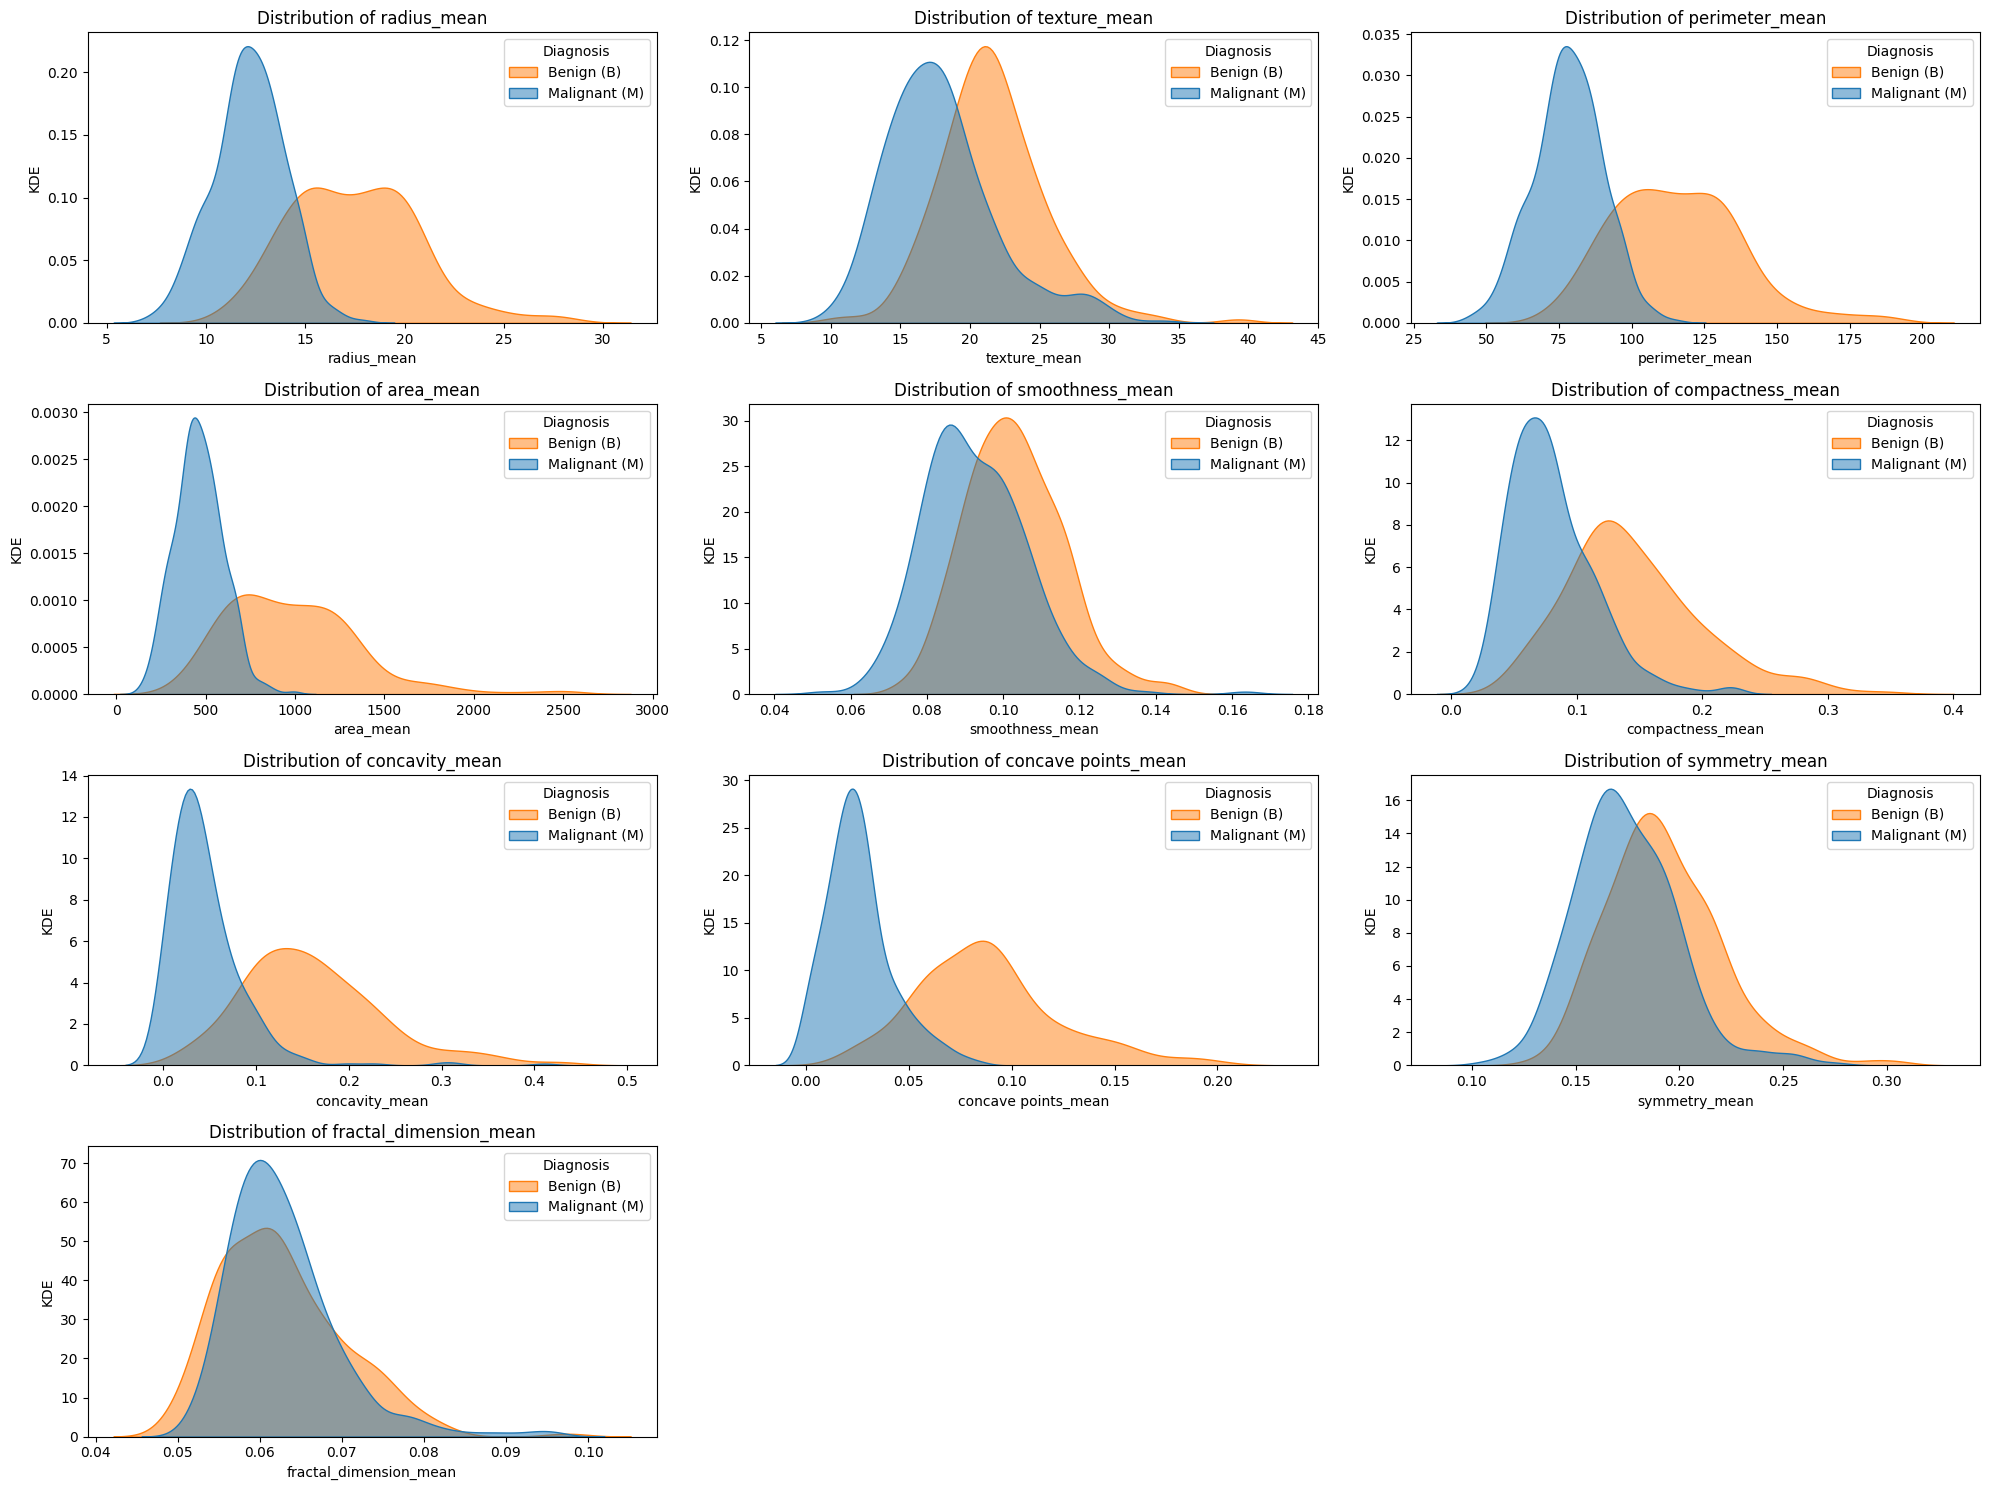

In [112]:
feature_columns = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
                   'smoothness_mean', 'compactness_mean', 'concavity_mean', 
                   'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

plt.figure(figsize=(20, 15))

for i, column in enumerate(feature_columns[:], 1):  
    plt.subplot(4, 3, i)

    sns.kdeplot(data=df, x=column, hue='diagnosis', 
                fill=True, alpha=0.5, common_norm=False)
    
    plt.title(f'Distribution of {column}', fontsize=12)
    plt.xlabel(column)
    plt.ylabel('KDE')
    plt.legend(title='Diagnosis', labels=['Benign (B)', 'Malignant (M)'])

plt.tight_layout()
plt.show()

In [113]:
stats_summary = []

for column in feature_columns:
    column_stats = df.groupby('diagnosis')[column].agg(['skew', 'kurt']).reset_index()
    column_stats['Feature'] = column
    stats_summary.append(column_stats)
    
stats_df = pd.concat(stats_summary)
print(stats_df)

   diagnosis      skew       kurt                 Feature
0          0 -0.083799  -0.012283             radius_mean
1          1  0.501902   0.374387             radius_mean
0          0  0.981344   1.219651            texture_mean
1          1  0.703543   2.379109            texture_mean
0          0 -0.064684  -0.016463          perimeter_mean
1          1  0.604931   0.591229          perimeter_mean
0          0  0.342265   0.309498               area_mean
1          1  1.117668   2.306042               area_mean
0          0  0.663448   1.855395         smoothness_mean
1          1  0.479751   0.431933         smoothness_mean
0          0  1.212443   2.286519        compactness_mean
1          1  0.836768   0.855188        compactness_mean
0          0  3.473264  20.834811          concavity_mean
1          1  0.901628   1.152738          concavity_mean
0          0  0.924965   1.038008     concave points_mean
1          1  0.739092   0.730094     concave points_mean
0          0  

# Box plot:

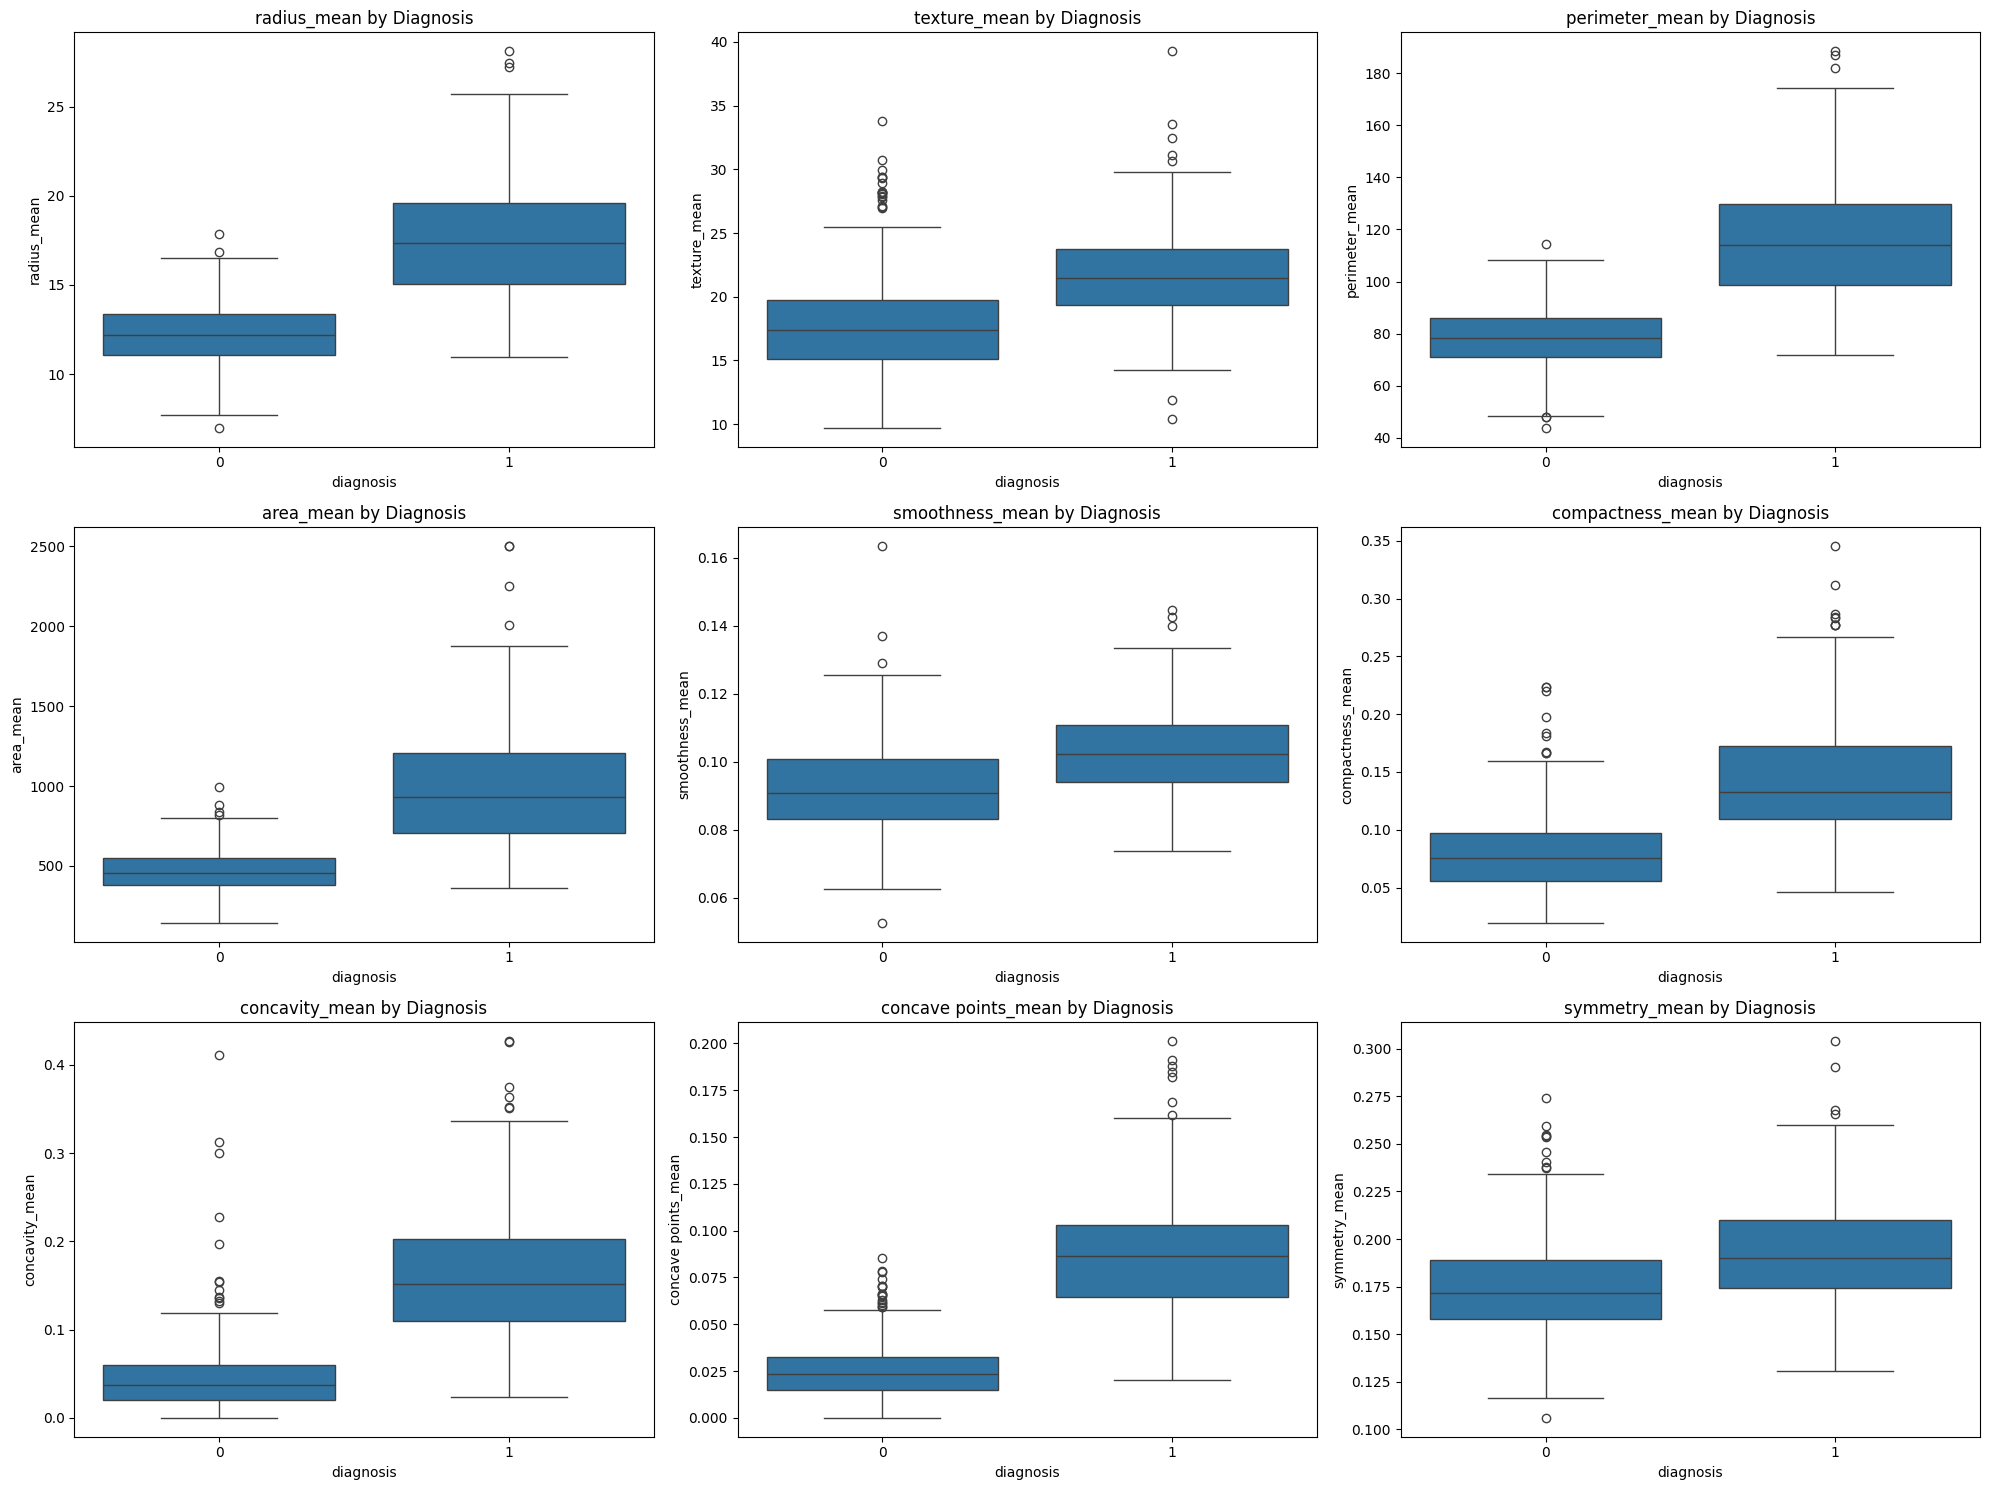

In [114]:
plt.figure(figsize=(20, 15))
for i, column in enumerate(feature_columns[:9], 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='diagnosis', y=column)
    plt.title(f'{column} by Diagnosis')
plt.tight_layout()
plt.show()

Все показатели M-опухоли больше, нежели B.

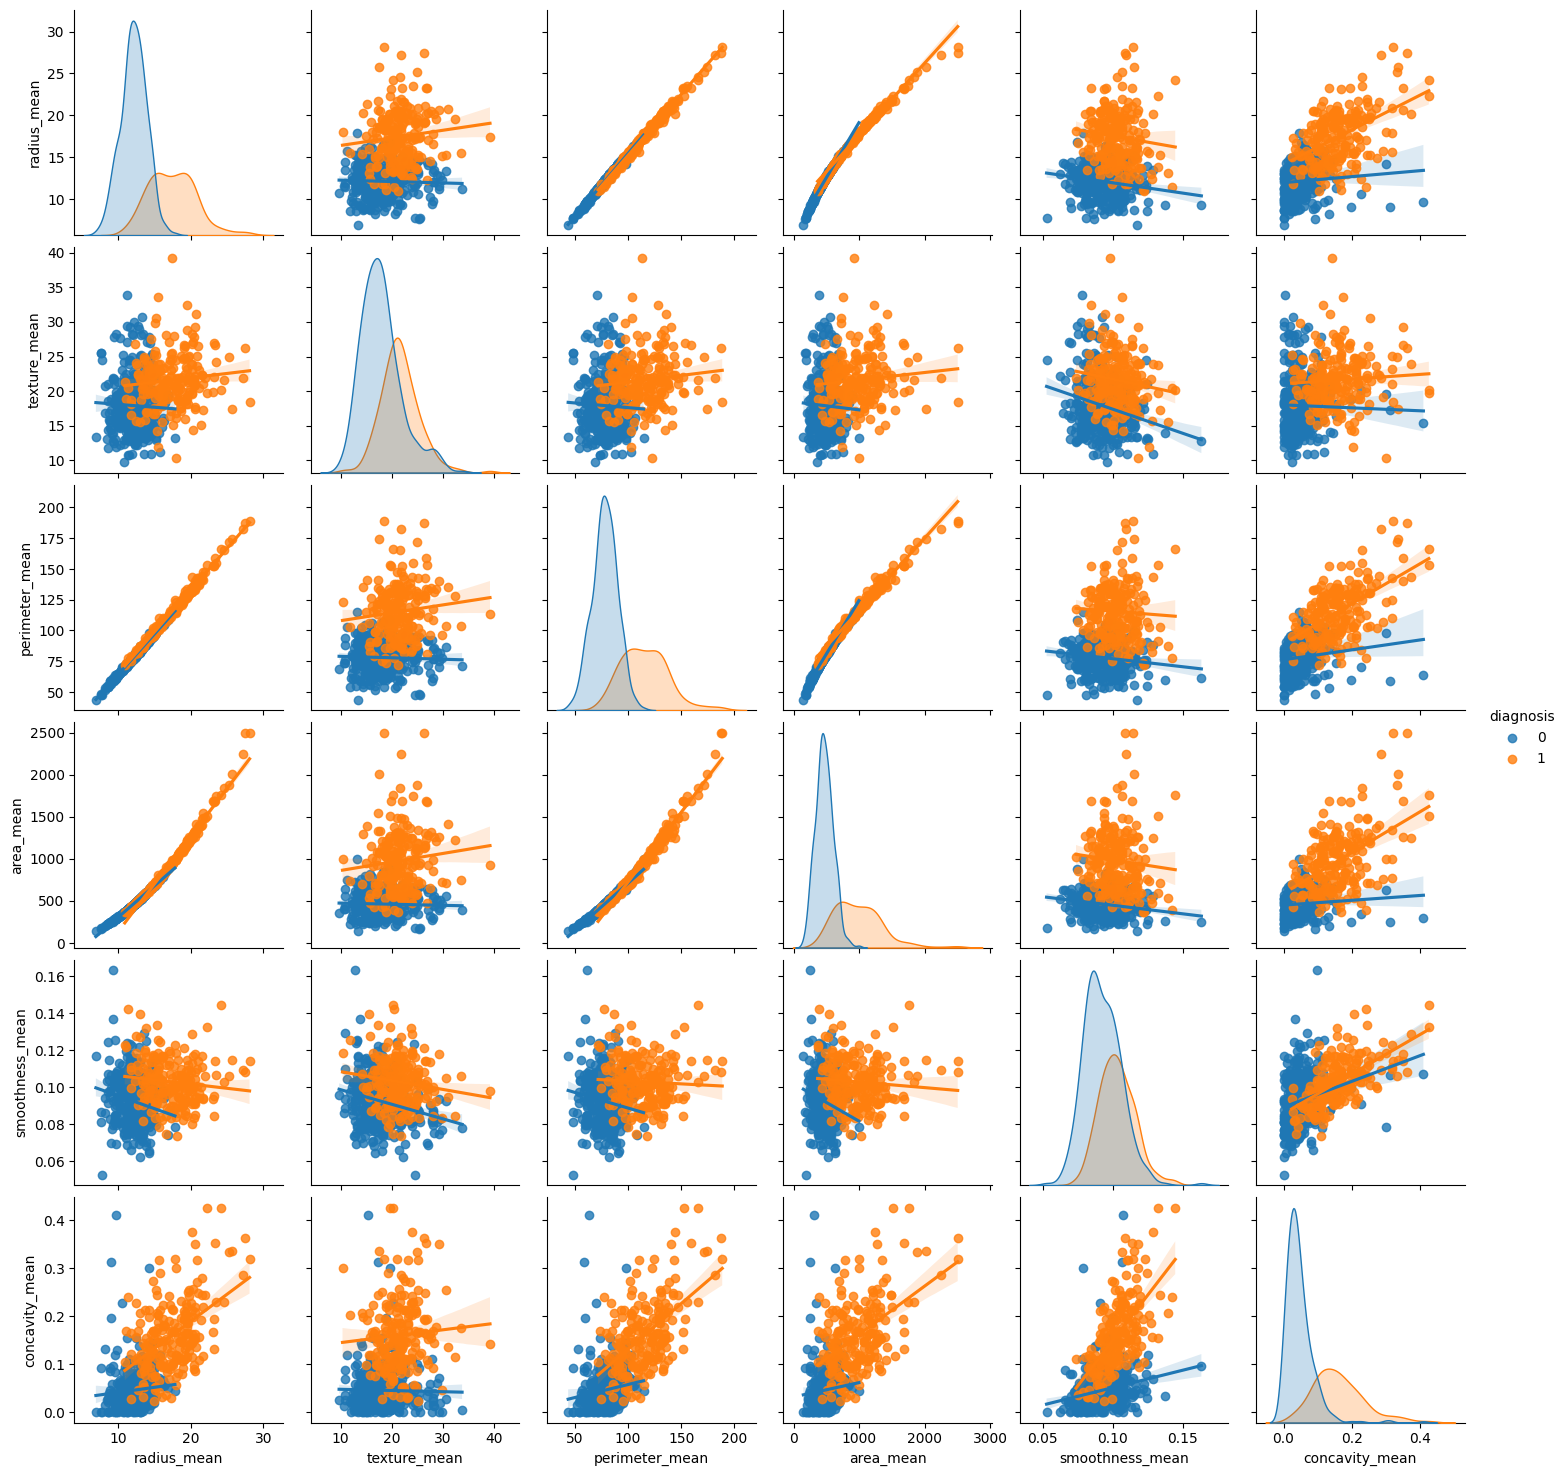

In [115]:
sns.pairplot(df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'concavity_mean', 'diagnosis']], hue='diagnosis',
             kind='reg')

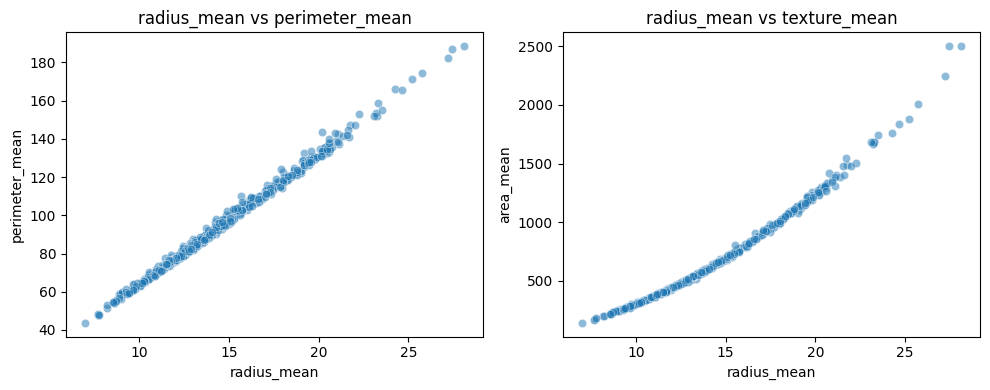

In [116]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='radius_mean', y='perimeter_mean', alpha=0.5)
plt.title('radius_mean vs perimeter_mean')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='radius_mean', y='area_mean', alpha=0.5)
plt.title('radius_mean vs texture_mean')

plt.tight_layout()
plt.show()

Проверим корреляции признаков

In [117]:
pearson_corr = df['radius_mean'].corr(df['perimeter_mean'])
print(f"radius_mean perimeter_mean corr: {pearson_corr:.3f}")


pearson_corr = df['radius_mean'].corr(df['area_mean'], method='spearman')
print(f"radius_mean area_mean corr: {pearson_corr:.3f}")


radius_mean perimeter_mean corr: 0.998
radius_mean area_mean corr: 1.000


Три признака связаны между собой, и можно оставить только один из них. Пусть это будет radius_mean.

In [118]:
df = df.drop(['perimeter_mean', 'area_mean'], axis=1)

## Scaling

Буду пробовать 3 вида масштабирования: StandardScaler, MinMaxScaler, RobustScaler

- **почему масштабирование важно для KNN**:
Алгоритм основан на расстояниях в пространстве. Без масштабирования признаки с большими значениями доминируют, а с маленькими -- игнорируются.
- **почему нельзя подбирать параметры на тестовой выборке**: ну потому что тестовая выборка -- это данные, которые модель якобы не видела и не знает, как их классифицировать. Если использовать параметры, вычисленные на самой тестовой выборке, то модель, кончено, будет хорошо работать на этой выборке, но на новых данных, которые она видит впервые, могут быть разочарующие результаты.

In [119]:
X = df.drop(columns=['diagnosis', 'id'])
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # stratify для сохранения пропорции классов в обеих выборках

X_train.shape, X_test.shape

scaler = StandardScaler()


X_train_std_scaler = scaler.fit_transform(X_train)
X_test_std_scaler = scaler.transform(X_test)


scaler1 = MinMaxScaler()


X_train_minmax_scaler = scaler1.fit_transform(X_train)
X_test_minmax_scaler = scaler1.transform(X_test)

scaler2 = RobustScaler()
X_train_robust = scaler2.fit_transform(X_train)
X_test_robust = scaler2.transform(X_test)


# KNN training

## KNN with RobustScaler
RobustScaler обычно применяется на данных с выбросами/аномалиями, чего в моих данных особо нет, но попробуем.

In [120]:
neigh0 = KNeighborsClassifier(n_neighbors=3) #euclidian metric
neigh0.fit(X_train_robust, y_train)
y_pred0 = neigh0.predict(X_test_robust) 
balanced_accuracy_score(y_pred0, y_test)

0.9692982456140351

In [121]:
f1_score(y_pred0, y_test)

0.9421487603305785

## KNN with Standard Scaling

In [122]:

neigh = KNeighborsClassifier(n_neighbors=5) #euclidian metric
neigh.fit(X_train_std_scaler, y_train)
y_pred = neigh.predict(X_test_std_scaler) #пригодится при подсчете ошибок
#neigh.score(X_test_std_scaler, y_test)
balanced_accuracy_score(y_pred, y_test)

0.9692982456140351

In [123]:
precision_score(y_test, y_pred)

1.0

In [124]:
recall_score(y_test, y_pred)

0.890625

модель не обнаружила 11% больных

In [125]:
f1_score(y_test, y_pred)

0.9421487603305785

In [126]:
neigh1 = KNeighborsClassifier(n_neighbors=5, weights='distance')
neigh1.fit(X_train_std_scaler, y_train)
y_pred1 = neigh1.predict(X_test_std_scaler) 

balanced_accuracy_score(y_pred1, y_test)


0.9692982456140351

In [127]:
f1_score(y_test, y_pred1)

0.9421487603305785

На достаточно малом количестве соседей результаты с весами uniform и distance совпадают. На самом деле, меняя значение числа соседей, результаты лучше то с одними весами, то с другими. Дабы не загромождать ноутбук, не буду выводить эти результаты, они не сильно отличаются. Более доскональный подбор числа соседей будет ниже.

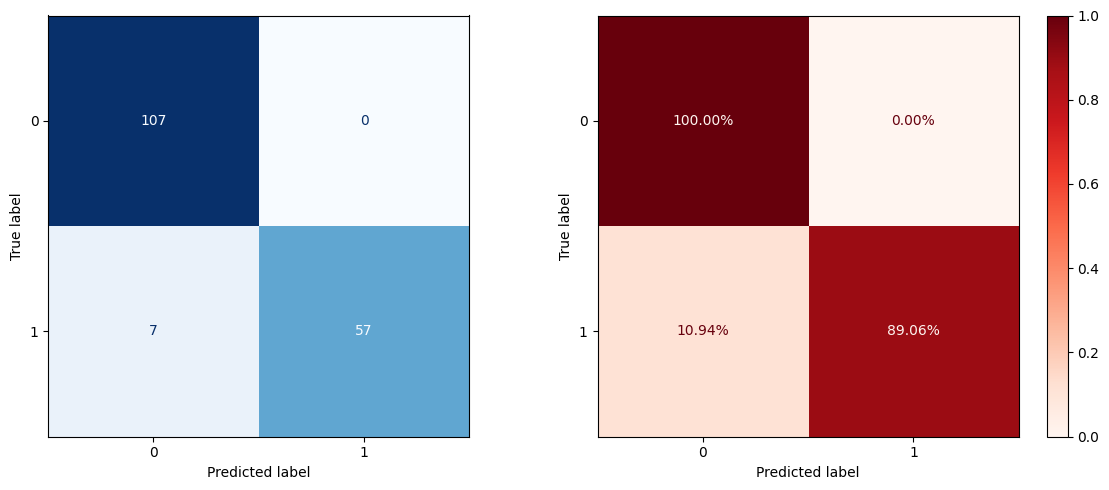

In [128]:
cm_absolute = confusion_matrix(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

disp_abs = ConfusionMatrixDisplay(confusion_matrix=cm_absolute)
disp_abs.plot(ax=ax[0], cmap='Blues', colorbar=False)


disp_pct = ConfusionMatrixDisplay(confusion_matrix=cm_normalized)
disp_pct.plot(ax=ax[1], cmap='Reds', values_format='.2%')

plt.tight_layout()
plt.show()

Матрица ошибок для 5-NN модели со стандартным масштабированием, евклидовой метрикой и весами uniform. Вполне достойно

In [129]:
neigh1 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='manhattan')
neigh1.fit(X_train_std_scaler, y_train)
y_pred1 = neigh1.predict(X_test_std_scaler) 
balanced_accuracy_score(y_pred1, y_test)


0.9734513274336283

In [130]:
recall_score(y_test, y_pred1)

0.90625

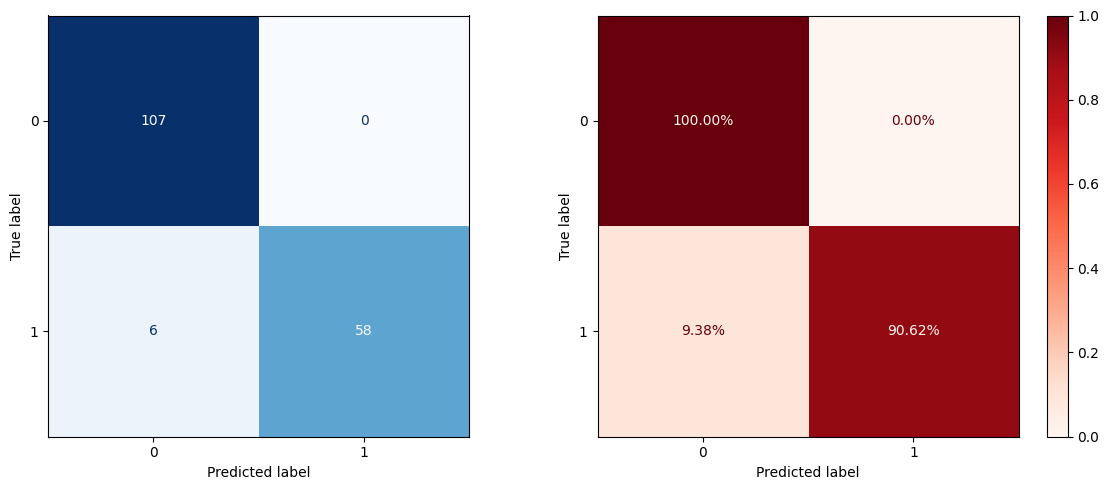

In [131]:
cm_absolute = confusion_matrix(y_test, y_pred1)
cm_normalized = confusion_matrix(y_test, y_pred1, normalize='true')


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

disp_abs = ConfusionMatrixDisplay(confusion_matrix=cm_absolute)
disp_abs.plot(ax=ax[0], cmap='Blues', colorbar=False)


disp_pct = ConfusionMatrixDisplay(confusion_matrix=cm_normalized)
disp_pct.plot(ax=ax[1], cmap='Reds', values_format='.2%')

plt.tight_layout()
plt.show()

Матрица ошибок для 5-NN модели со стандартным масштабированием, манхэттеновской метрикой и весами uniform. Несильно лучше

In [132]:
neigh1 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski', p=3)
neigh1.fit(X_train_std_scaler, y_train)
y_pred1 = neigh1.predict(X_test_std_scaler) 
balanced_accuracy_score(y_pred1, y_test)


0.9612068965517242

Результаты с метрикой Минковского не впечатляют и более затратны в вычислении.

## KNN with MinMax Scaling

In [133]:
neigh2 = KNeighborsClassifier(n_neighbors=5) #euclidian metric
neigh2.fit(X_train_minmax_scaler, y_train)
y_pred2 = neigh2.predict(X_test_minmax_scaler) 
balanced_accuracy_score(y_pred2, y_test)

0.9776785714285714

Чуть лучше Standard Scaler'а

In [134]:
neigh3 = KNeighborsClassifier(n_neighbors=5, metric='manhattan') #euclidian metric
neigh3.fit(X_train_minmax_scaler, y_train)
y_pred3 = neigh3.predict(X_test_minmax_scaler) 
balanced_accuracy_score(y_pred3, y_test)

0.9647397094430993

Manhattan metric показывает результат хуже

In [135]:
neigh3 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=8) 
neigh3.fit(X_train_minmax_scaler, y_train)
y_pred3 = neigh3.predict(X_test_minmax_scaler) 
balanced_accuracy_score(y_pred3, y_test)

0.9863636363636363

Попробовал разные степени p (3-9). Наилучшим образом себя показали 5 и 8.

In [136]:
recall_score(y_pred3, y_test)

1.0

In [137]:
precision_score(y_pred3, y_test)

0.953125

In [138]:
f1_score(y_pred3, y_test)

0.976

Рекол =1, это очень хороший показатель. Он показывает, что модель обнаружила все случаи злокачественных опухолей. f1_score -- комбинация precision и recall. В целом высокий и выше, чем при стандартном масштабировании.

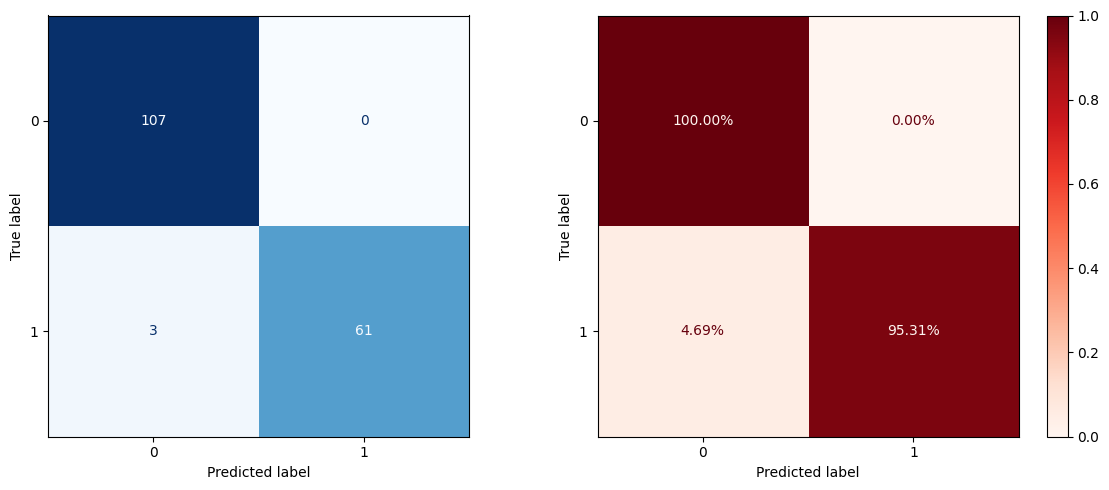

In [139]:
cm_absolute3 = confusion_matrix(y_test, y_pred3)
cm_normalized3 = confusion_matrix(y_test, y_pred3, normalize='true')


fig3, ax3 = plt.subplots(1, 2, figsize=(12, 5))

disp_abs3 = ConfusionMatrixDisplay(confusion_matrix=cm_absolute3)
disp_abs3.plot(ax=ax3[0], cmap='Blues', colorbar=False)


disp_pct3 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized3)
disp_pct3.plot(ax=ax3[1], cmap='Reds', values_format='.2%')

plt.tight_layout()
plt.show()

## KNN w/o any scaling
По заданию необходимо сравнить обучение модели без примененного масштабирования. Посмотрим результаты

In [140]:
neigh4 = KNeighborsClassifier(n_neighbors=5) #euclidian metric
neigh4.fit(X_train, y_train)
y_pred4 = neigh4.predict(X_test) 
balanced_accuracy_score(y_pred4, y_test)

0.9357627666451196

Ожидаемо результат хуже 

Будем работать уже с MinMax Scaling, так как потенциально оно наилучшее. GridSearchCV, реализованный вручную через cross_val_score:

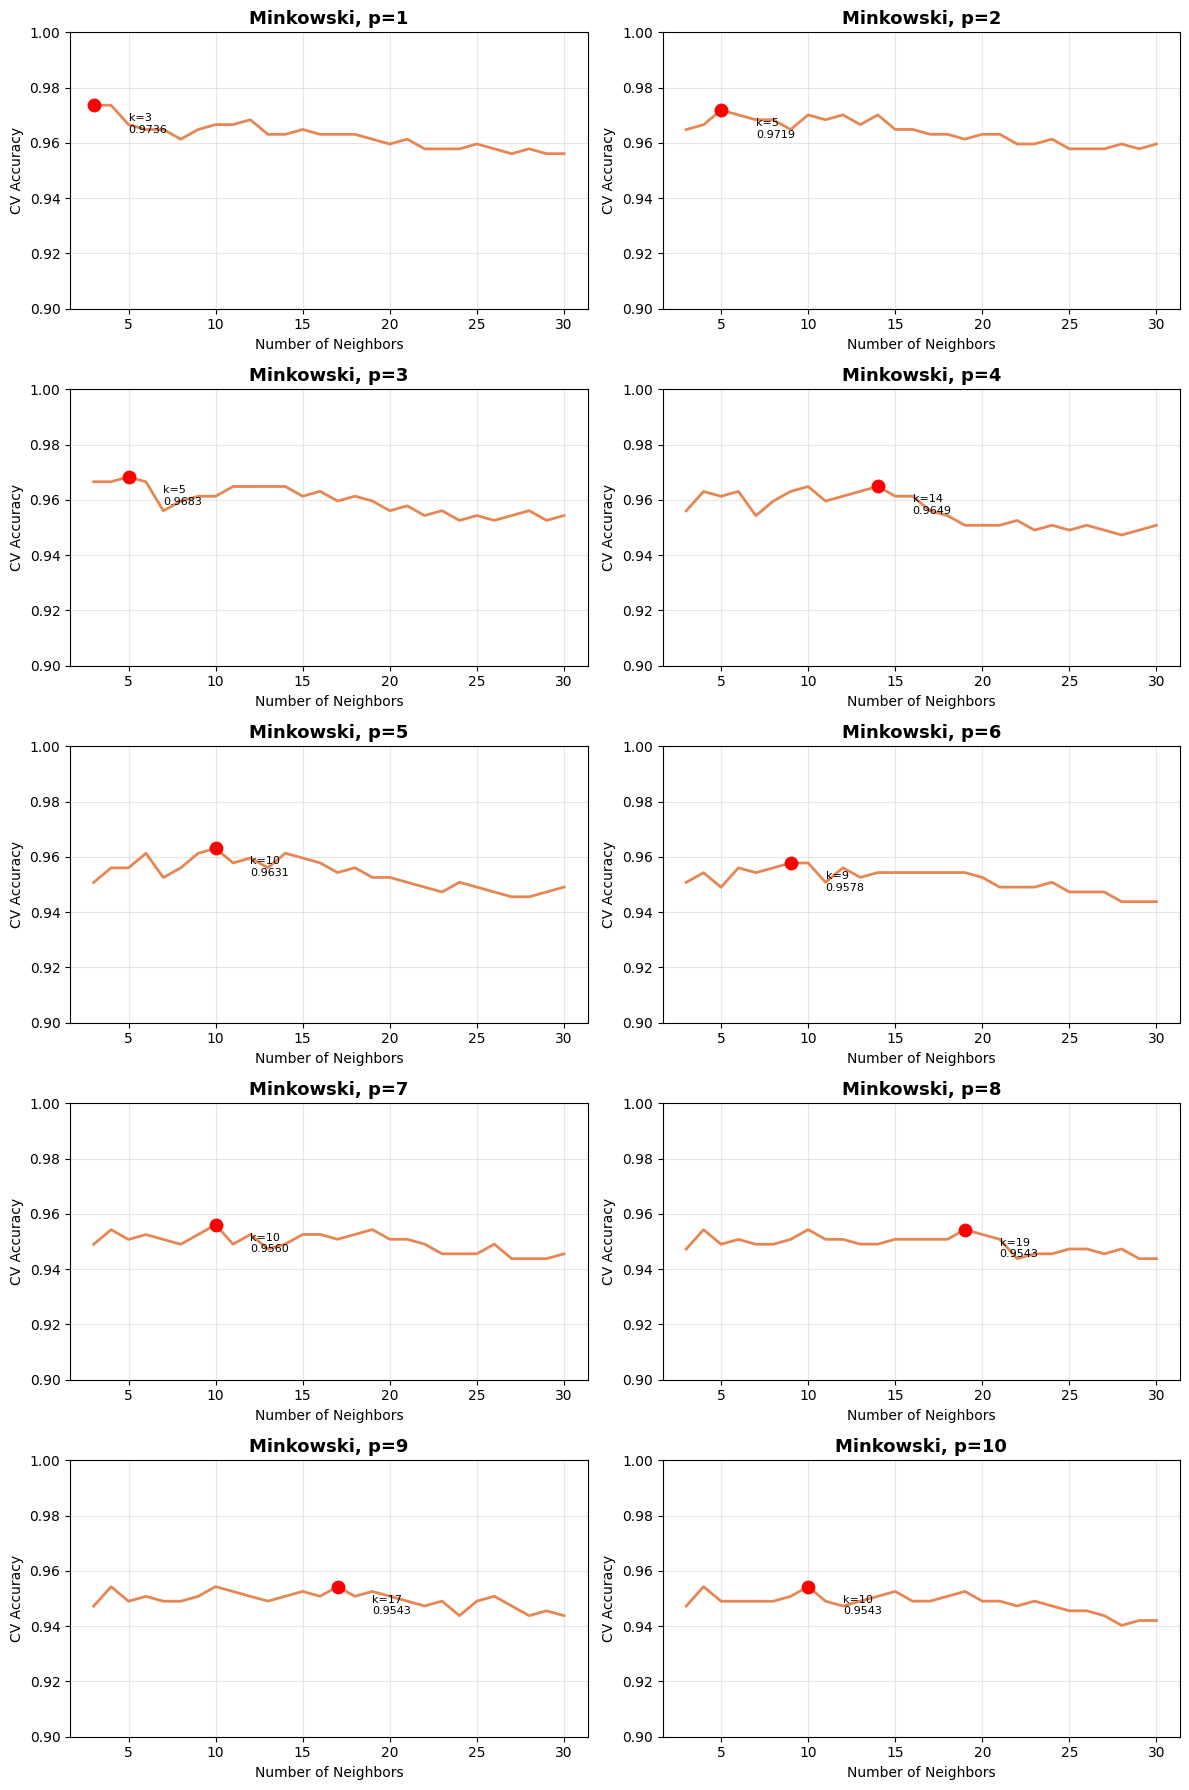


Best result (5-fold CV with correct scaling):
  p = 1
  k = 3
  CV Accuracy = 0.9736

--------------------------------------------------
All metrics for best model With standard deviations:
- Accuracy: 0.973638 ± 0.009610
- Balanced Accuracy: 0.968453 ± 0.012524
- Precision: 0.981058 ± 0.017499
- Recall: 0.948173 ± 0.027585
- F1-score: 0.963949 ± 0.013459


In [141]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

neighbors = np.arange(3, 31)
p_values = range(1, 11)


cv_scores = np.empty((len(p_values), len(neighbors)))


for i, p in enumerate(p_values):
    for j, k in enumerate(neighbors):
        pipeline = Pipeline([
            ('scaler', MinMaxScaler()),
            ('knn', KNeighborsClassifier(n_neighbors=k, metric='minkowski', 
                                        p=p, weights='distance'))
        ])
        
        scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
        cv_scores[i, j] = scores.mean()
        


fig, axs = plt.subplots(5, 2, figsize=(12, 18))
axs = axs.flatten()

for idx, p in enumerate(p_values):
    ax = axs[idx]
    ax.plot(neighbors, cv_scores[idx], color='#E68753', lw=2)
    ax.set_xlabel('Number of Neighbors')
    ax.set_title(f'Minkowski, p={p}', fontsize=13, fontweight='bold')
    ax.set_ylabel('CV Accuracy')
    ax.set_xticks(np.arange(0, 41, 5))
    ax.set_ylim(0.90, 1.0)
    ax.grid(True, alpha=0.3)
    

    best_k_idx = np.argmax(cv_scores[idx])
    best_k = neighbors[best_k_idx]
    best_score = cv_scores[idx][best_k_idx]
    ax.scatter(best_k, best_score, color='red', s=80, zorder=5)
    ax.annotate(f'k={best_k}\n{best_score:.4f}', 
                xy=(best_k, best_score), xytext=(best_k+2, best_score-0.01),
                fontsize=8)

plt.tight_layout()
plt.show()

best_p_idx, best_k_idx = np.unravel_index(np.argmax(cv_scores), cv_scores.shape)
best_p = p_values[best_p_idx]
best_k = neighbors[best_k_idx]
best_score = cv_scores[best_p_idx, best_k_idx]

print(f"\nBest result (5-fold CV with correct scaling):")
print(f"  p = {best_p}")
print(f"  k = {best_k}")
print(f"  CV Accuracy = {best_score:.4f}")


final_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', 
                                p=best_p, weights='distance'))
])

scoring_metrics = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_results = cross_validate(
    final_pipeline, X, y, 
    cv=5, 
    scoring=scoring_metrics,
    return_train_score=False
)


print("\n" + "-"*50)
print("All metrics for best model With standard deviations:")
print(f"- Accuracy: {cv_results['test_accuracy'].mean():.6f} ± {cv_results['test_accuracy'].std():.6f}")
print(f"- Balanced Accuracy: {cv_results['test_balanced_accuracy'].mean():.6f} ± {cv_results['test_balanced_accuracy'].std():.6f}")
print(f"- Precision: {cv_results['test_precision'].mean():.6f} ± {cv_results['test_precision'].std():.6f}")
print(f"- Recall: {cv_results['test_recall'].mean():.6f} ± {cv_results['test_recall'].std():.6f}")
print(f"- F1-score: {cv_results['test_f1'].mean():.6f} ± {cv_results['test_f1'].std():.6f}")


 RandomizedSearchCV показал себя хуже, что ожидаемо

In [142]:
from sklearn.model_selection import RandomizedSearchCV


pipeline_rs = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(metric='minkowski', weights='distance'))
])

param_dist = {
    'knn__n_neighbors': range(2, 51),      
    'knn__p': range(1, 20),
    'knn__weights': ['uniform', 'distance']
}

random_search = RandomizedSearchCV(
    pipeline_rs,
    param_dist,
    n_iter=50,              
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=1,
    verbose=1
)

random_search.fit(X, y)


print(f"\nRandomizedSearchCV best score: {random_search.best_score_:.4f}")
print(f"Best parameters: {random_search.best_params_}")


print(f"  GridSearchCV:      p={best_p}, k={best_k}, acc={best_score:.4f}")
print(f"  RandomizedSearchCV:            p={random_search.best_params_['knn__p']}, "
      f"k={random_search.best_params_['knn__n_neighbors']}, acc={random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

RandomizedSearchCV best score: 0.9666
Best parameters: {'knn__weights': 'uniform', 'knn__p': 2, 'knn__n_neighbors': 12}
  GridSearchCV:      p=1, k=3, acc=0.9736
  RandomizedSearchCV:            p=2, k=12, acc=0.9666


## Summary

- **почему модель работает именно так**:  M - опухоли  имеют большие значения по признакам:
 Доброкачественные и злокачественные опухоли не пересекаются в пространстве: расстояние между точками двух классов достаточное. Ниже будет показана PCA визуализация, где видно что датасет достаточно кластеризован. 
- **какие ограничения есть у KNN на вашем датасете**: 30 параметров с разной значимостью, а алгоритм считает все параметры равнозначными. много данных приходится хранить: если расширять датасет, то модель будет медленнее предсказывать и больше памяти занимать, так как недостаток KNN - необходимо хранить все образцы.

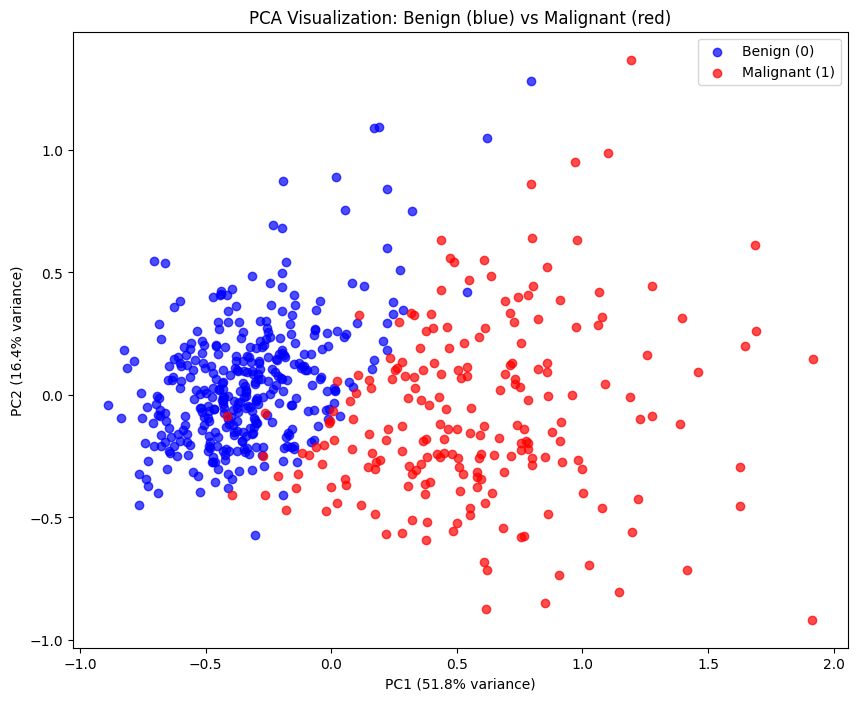

PC1 explains: 51.79%
PC2 explains: 16.42%
Total: 68.20%


In [143]:
from sklearn.decomposition import PCA


scaler1 = MinMaxScaler()
X_scaled = scaler1.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))

colors = {0: 'blue', 1: 'red'}
labels = {0: 'Benign (0)', 1: 'Malignant (1)'}

for class_value in [0, 1]:
    mask = y == class_value
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=colors[class_value], label=labels[class_value], alpha=0.7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA Visualization: Benign (blue) vs Malignant (red)')
plt.legend()
plt.show()


print(f"PC1 explains: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total: {pca.explained_variance_ratio_.sum():.2%}")

Таким образом, я бы использовал 
- 3-NN модель
- с Manhatten метрикой
- с данными масштабированные через нормализацию (мин макс) 

C такими показателями

- Accuracy: 0.973638
- Balanced Accuracy: 0.968453
- Precision: 0.981058
- Recall: 0.948173
- F1-score: 0.963949

На моменте обучения KNN иногда были и лучше результаты, но это скорее случайности
